<a href="https://colab.research.google.com/github/alejandrobernalchavez/progralll-2024-semi/blob/Bloque-3/ia_de_numero.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#importar las librerias necesarias.
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import tensorflow_datasets as tfds

In [2]:
#cargamos el dataset
dataset, metadata = tfds.load('mnist', as_supervised=True, with_info=True)
datos_entrenamiento, datos_prueba = dataset['train'], dataset['test']
#print(datos_entrenamiento)

Dl Completed...:   0%|          | 0/5 [00:00<?, ? file/s]

Dataset mnist downloaded and prepared to /root/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


In [3]:
#asignacion de etiquetas
numero_letras = ["Cero", "Uno", "Dos", "Tres", "Cuatro", "Cinco", "Seis", "Siete", "Ocho", "Nueve"]


In [5]:
#pasar los datos del dataset a variables
numeros_ejemplo_entrenamiento = metadata.splits['train'].num_examples
#print(numeros_ejemplo_entrenamiento)

numeros_ejemplo_prueba = metadata.splits['test'].num_examples
#print(numeros_ejemplo_prueba)

In [6]:
img = datos_prueba.take(1)
print(img)

<_TakeDataset element_spec=(TensorSpec(shape=(28, 28, 1), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>


In [7]:
#funcion normalizadora de los pixeles de 0 a 255 para que vaya de 0 a 1
def normalizacion(imagenes, etiquetas):
  imagenes = tf.cast(imagenes, tf.float32)
  imagenes /= 255 # 138/255 = 0.541176
  return imagenes, etiquetas

In [8]:
#normalizamos los datos de entrenamiento y prueba
datos_entrenamiento = datos_entrenamiento.map(normalizacion)
datos_prueba = datos_prueba.map(normalizacion)

In [9]:
#creamos el modelo de nuestra red neuronal.
modelo = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28, 1)),
    tf.keras.layers.Dense(64, activation=tf.nn.relu),
    tf.keras.layers.Dense(64, activation=tf.nn.relu),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
#compilamos el modelo de la red neuronal.
modelo.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
#entrenamos la red neuronal por lotes.
tamano_lote = 32 #60,000/32 = 1875 imagenes.
datos_entrenamiento = datos_entrenamiento.repeat().shuffle(numeros_ejemplo_entrenamiento).batch(tamano_lote)
datos_prueba = datos_prueba.repeat().shuffle(numeros_ejemplo_prueba).batch(tamano_lote)
#


In [12]:
#entrenamos nuestro modelo de datos.
modelo.fit(datos_entrenamiento, epochs=5,
           steps_per_epoch=math.ceil(numeros_ejemplo_entrenamiento/tamano_lote))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.8594 - loss: 0.4894
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9580 - loss: 0.1386
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9722 - loss: 0.0914
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9747 - loss: 0.0797
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9799 - loss: 0.0626


In [13]:
#evaluamos el modelo.
test_loss, test_accuracy = modelo.evaluate(datos_prueba, steps=math.ceil(numeros_ejemplo_prueba/tamano_lote))
print('Resultado de las pruebas: ', test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9705 - loss: 0.0978
Resultado de las pruebas:  0.9718450307846069


In [14]:
#convertir en mtrices las imganes usando numpy
for imagenes_prueba, etiquetas_prueba in datos_prueba.take(1):
  imagenes_prueba = imagenes_prueba.numpy()
  etiquetas_prueba = etiquetas_prueba.numpy()
  predicciones = modelo.predict(imagenes_prueba)
  print(predicciones)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
[[2.62960032e-09 1.37563043e-11 7.17501579e-12 3.63099298e-06
  6.63275023e-06 9.19597980e-08 5.47536669e-12 1.63246316e-09
  8.74038524e-05 9.99902189e-01]
 [2.17841123e-04 2.59054246e-07 2.08598692e-07 1.19787255e-05
  1.36246518e-11 3.34551121e-04 2.78503194e-06 7.31295524e-10
  9.99429822e-01 2.48526226e-06]
 [8.65219863e-06 7.05436491e-07 1.64930298e-05 1.52708963e-02
  2.35324973e-04 4.36097571e-06 4.24150642e-07 3.54951626e-05
  9.82165616e-03 9.74606037e-01]
 [2.29597688e-07 6.46460045e-13 4.27617728e-08 2.02912904e-08
  7.37685434e-12 1.55655142e-10 1.46764309e-10 4.54653845e-14
  9.99999583e-01 1.07154257e-07]
 [3.22411993e-11 1.17835646e-13 2.01743555e-09 1.93484638e-12
  1.97012398e-08 7.31168626e-10 9.99999940e-01 1.66792673e-11
  4.73557193e-09 4.63127842e-15]
 [8.29707913e-10 1.99212445e-05 1.60490217e-07 9.98977184e-01
  1.40428585e-06 9.62513557e-04 1.04387954e-09 7.71018495e-06
  7.12056953e-06 2.37943168e-05]
 [1.81681813e-07 1.

In [15]:
def graficar_imagen(i, predicciones_array, etiquetas_reales, imagenes):
  predicciones_array, etiqueta_real, img = predicciones_array[i], etiquetas_reales[i], imagenes[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img[...,0], cmap=plt.cm.binary)

  etiqueta_prediccion = np.argmax(predicciones_array)
  if etiqueta_prediccion == etiqueta_real:
    color = 'blue'
  else:
    color = 'red'
  plt.xlabel("Prediccion: {}".format(numero_letras[etiqueta_prediccion]), color=color)

In [16]:
#graficamos los valores de las matrices.
def graficar_valores_predicciones(i, predicciones_array, etiquetas_reales):
  predicciones_array, etiqueta_real = predicciones_array[i], etiquetas_reales[i]
  plt.grid(False)
  plt.xticks(range(10))
  plt.yticks([])
  thisplot = plt.bar(range(10), predicciones_array, color="#888888")
  plt.ylim([0, 1])
  etiqueta_prediccion = np.argmax(predicciones_array)

  thisplot[etiqueta_prediccion].set_color('red')
  thisplot[etiqueta_real].set_color('blue')

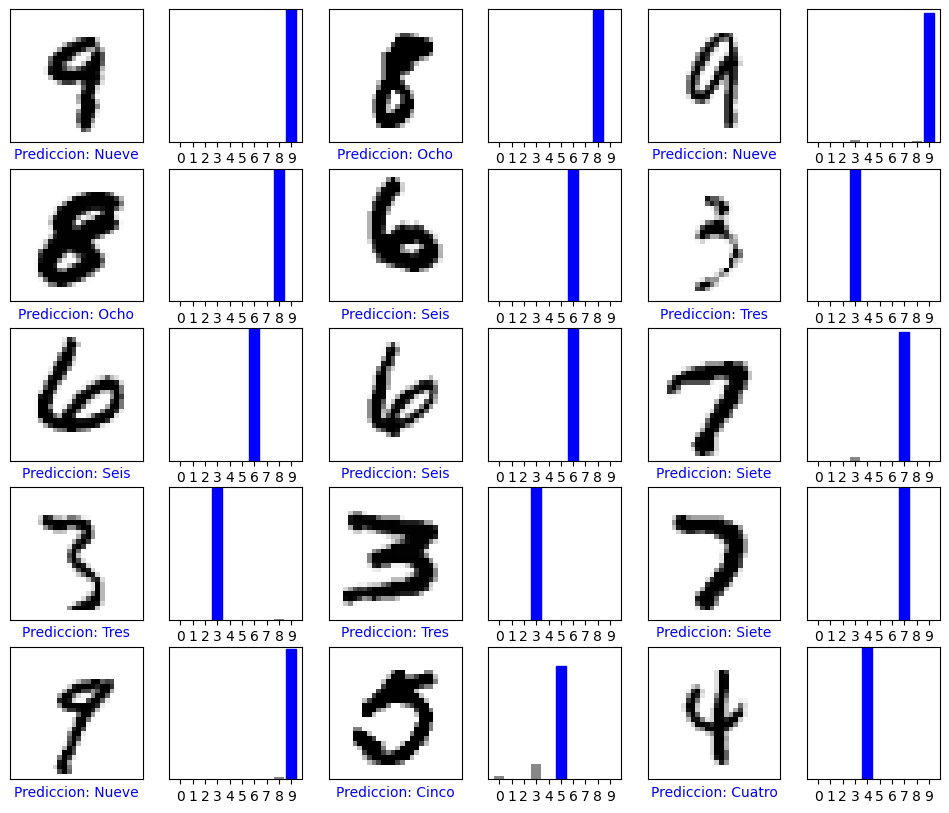

In [17]:
#Realizamos la grafica por cada imagen.
num_filas = 5
num_columnas = 3
num_imagenes = num_filas*num_columnas
plt.figure(figsize=(2*2*num_columnas, 2*num_filas))
for i in range(num_imagenes):
  plt.subplot(num_filas, 2*num_columnas, 2*i+1)
  graficar_imagen(i, predicciones, etiquetas_prueba, imagenes_prueba)
  plt.subplot(num_filas, 2*num_columnas, 2*i+2)
  graficar_valores_predicciones(i, predicciones, etiquetas_prueba)
plt.show()